# Relay Races and Revolving Doors

This notebook contains the text from Chapter 2 of *[Probably Overthinking It: How to Use Data to Answer Questions, Avoid Statistical Traps, and Make Better Decisions](https://greenteapress.com/wp/probably-overthinking-it)* (University of Chicago Press, 2023), along with the supporting code used in the analysis.

*Probably Overthinking It* is available from [Bookshop.org](https://bookshop.org/a/98697/9780226822587) and [Amazon](https://amzn.to/3Kp629E) (affiliate links).

[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/ProbablyOverthinkingIt/blob/book/notebooks/inspection.ipynb).

I gave a talk related to this chapter at PyData NYC 2019. You can [watch the video here](https://www.youtube.com/watch?v=cXWTHfvycyM).

In [1]:
# Install empirical dist if we don't already have it

try:
    import empiricaldist
except ImportError:
    !pip install empiricaldist

In [2]:
# download utils.py

from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)
        
download("https://github.com/AllenDowney/ProbablyOverthinkingIt/raw/book/notebooks/utils.py")

In [3]:
import matplotlib.pyplot as plt
from utils import set_pyplot_params

set_pyplot_params()

In [4]:
import pandas as pd
import numpy as np

# Set the random seed so we get the same results every time
np.random.seed(17)

When you run 209 miles, you have a lot of time to think. In 2010, I was
a member of a 12-person team that ran a 209-mile relay race in New Hampshire.

Long-distance relay races are an unusual format, and this was the first
(and last!) time I participated in one. I ran the third leg, so when I
joined the race, it had been going for a few hours and runners were
spread out over several miles of the course.

After I ran a few miles, I noticed something unusual:

* There were more fast runners in the race than I expected. Several times I was overtaken by runners much faster than me.

* There were also more slow runners than I expected. When I passed other runners, I was often much faster than them.

At first I thought this pattern might reflect the kind of people who
sign up for a 209-mile race. Maybe, for some reason, this format appeals
primarily to runners who are much faster than average or much slower,
and not as much to middle-of-the-pack runners like me.

After the race, with more oxygen available to my brain, I realized that
this explanation is wrong. To my embarrassment, I was fooled by a common
statistical error, one that I teach students in my classes!

The error is called length-biased sampling, and its effect is called the
inspection paradox. If you have not heard of it, this chapter will
change your life, because once you learn about the inspection paradox,
you see it everywhere.

To explain it, I'll start with simple examples and we will work our way
up. Some of the examples are fun, but some are more serious. For
example, length-biased sampling shows up in the criminal justice system
and distorts our perception of prison sentences and the risk of repeat
offenders.

But it's not all bad news; if you are aware of the inspection paradox,
sometimes you can use it to measure indirectly quantities that would be
hard or impossible to measure directly. As an example, I'll explain a
clever system used during the COVID pandemic to track infections and
identify superspreaders.

But let's start with class sizes.

## Class Size

Suppose you ask college students how big their classes are and average
the responses. The result might be 90. But if you ask the college for
the average class size, they might say 35. It sounds like someone is
lying, but they could both be right.

When you survey students, you oversample large classes; that is, large
classes are more likely to appear in your sample than small classes. For
example, if there are 10 students in a class, you have 10 chances to
sample that class; if there are 100 students, you have 100 chances. In
general, if the class size is $x$, it will be overrepresented in the
sample by a factor of $x$.

That's not necessarily a mistake. If you want to quantify student
experience, the average across students might be a more meaningful
statistic than the average across classes. But you have to be clear
about what you are measuring and how you report it.

The numbers in this example are real. They come from data reported by
Purdue University for undergraduate class sizes in the 2013--14 academic
year. From their report I estimated the actual distribution of class
sizes. In the following figure, the solid line shows the result as it
would be reported by the Dean. Most classes are smaller than 50, fewer
are between 50 and 100, and only a few are bigger than 100.

In [5]:
sizes = [(1, 1), (2, 9), (10, 19), (20, 29), (30, 39), (40, 49), (50, 99), (100, 300)]

counts = [138, 635, 1788, 1979, 796, 354, 487, 333]

Since the class sizes are specified in ranges, I used the following function to generate uniform random samples within each range.

In [6]:
def sample_int_from_bins(sizes, counts):
    """Generate a sample from binned data by sampling integers uniformly within each bin.

    Takes histogram-style binned data (ranges and counts) and generates
    a sample by drawing uniform random integer values within each bin range.
    This "expands" the binned data back into a discrete sample.

    sizes: sequence of (low, high) pairs representing bin boundaries
    counts: sequence of integers representing counts in each bin

    returns: NumPy array of sampled integer values
    """
    t = []
    for (low, high), count in zip(sizes, counts):
        sample = np.random.randint(low, high + 1, count)
        t.extend(sample)
    return np.array(t)

In [7]:
unbiased = sample_int_from_bins(sizes, counts)

The following function takes a sample and generates a new random sample, using the given weights.

In [8]:
def resample_weighted(sample, weights):
    """Generate a biased sample.

    sample: NumPy array
    weights: NumPy array

    returns: NumPy array
    """
    n = len(sample)
    p = weights / np.sum(weights)
    return np.random.choice(sample, n, p=p)

In [9]:
biased = resample_weighted(unbiased, unbiased)

In [10]:
# [Class size data originally posted here](https://www.purdue.edu/datadigest/2013-14/InstrStuLIfe/DistUGClasses.html)

# [Now archived here](https://web.archive.org/web/20160415011613/https://www.purdue.edu/datadigest/2013-14/InstrStuLIfe/DistUGClasses.html)


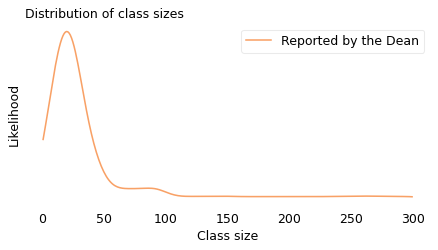

In [11]:
from utils import decorate, kdeplot

xs = np.arange(1, 300)
kdeplot(unbiased, xs, "Reported by the Dean", color="C1")

decorate(xlabel="Class size", title="Distribution of class sizes")

The upper bound in this figure, 300, is just my guess. The original data
indicates how many classes are bigger than 100, but it doesn't say how
much bigger. For this example, though, we don't have to be too precise.

Now suppose we sample students and ask how big their classes are. We can
simulate this process by drawing a random sample from the actual
distribution where the probability of sampling each class is
proportional to its size.
In the following figure, the dashed line shows the distribution of this simulated sample; the solid line shows the original distribution again.

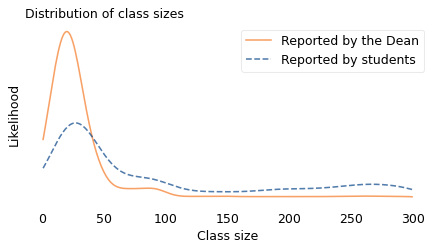

In [12]:
xs = np.arange(1, 300)
kdeplot(unbiased, xs, "Reported by the Dean", color="C1")
kdeplot(biased, xs, "Reported by students", ls="--")

decorate(xlabel="Class size", title="Distribution of class sizes")

In [13]:
np.mean(unbiased)

34.611827956989245

In [14]:
np.mean(biased)

92.59815668202765

The student sample is less likely to contain classes smaller than 40 and
more likely to contain larger classes. And the means of the
distributions are substantially different. The mean of the 
distribution reported by the Dean is about 35. The mean of the
distribution seen by students is about 90.

A discrepancy like this is called an "inspection paradox" because the
data you get depends on how you do the inspection, that is, how you
select the sample. If you visit a college and choose a classroom at
random (without regard for its size) the class you find inside will have
35 students, on average. But if you choose a student at random and follow
them to one of their classes, it will have 90 students, on average.

The apparent contradiction is paradoxical in the sense that it is
unexpected. It's not a true paradox in the sense used by philosophers,
like a self-contradictory statement. But it can certainly be confusing
and, if you are not familiar with the phenomenon, hard to explain.

## Unbiasing the Data

The inspection paradox can be a source of error if you think you
measured one thing and accidentally measured another. But in the right
hands, it can also be a tool.

For example, suppose you are a student at a large university and all
your classes have more than 100 students. The university web page says
the average class size is 35, but you suspect that's not accurate. You
ask the university for more data, but they won't give it to you. So you
decide to collect your own data.

Now, let's assume that you find a good quality random sample of
undergraduates at your university, with equal representation of all
departments and grade levels. And let's assume that the students in your
sample report the sizes of their classes accurately.

Because you have read this chapter, you know that the sample you
collected is biased; that is, it is more likely to include large classes
and less likely to include small classes. So you can't just compute the
mean of the biased data. That would be the answer to a different
question.

However, we don't just know that the sample you collected is biased; we
know precisely *how* it is biased, and that means we can reverse the
process and estimate the unbiased distribution.

In the previous section, I started with the unbiased distribution, as
reported by the university, and simulated what would happen if I asked
students about their classes. Now I will go the other way, starting with
the biased distribution as reported by students and simulating what
happens if we sample classes instead.

Specifically, I will draw a random sample from the student-reported
classes where the probability of choosing each class is *inversely*
proportional to its size. The size of the sample I generated is 500, which seems
like an amount of data it would be feasible to collect.

The following figure shows the result. Again, the solid line shows the
distribution as reported by the Dean, and the dashed line shows
the biased distribution reported by students.
The new, dotted line shows my estimate of the actual distribution,
constructed by drawing a sample from the biased distribution.


In [15]:
sample = np.random.choice(biased, 500)

In [16]:
reweighted = resample_weighted(sample, 1 / sample)

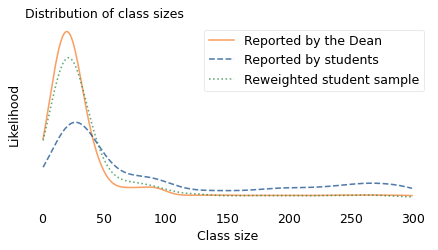

In [17]:
xs = np.arange(1, 300)
kdeplot(unbiased, xs, "Reported by the Dean", color="C1")
kdeplot(biased, xs, "Reported by students", ls="--")
kdeplot(reweighted, xs, "Reweighted student sample", color="C2", ls=":")

decorate(xlabel="Class size", title="Distribution of class sizes")

If the estimate were perfect, the solid and dotted lines would be
identical. But with a limited sample size, we underestimate the number
of small classes by a little and overestimate the number of classes with
50-80 students. Nevertheless, it works pretty well.

This strategy works in other cases where the actual distribution is not
available, deliberately or not. If we can collect a good quality sample
from the biased distribution, we can approximate the actual distribution
by drawing a sample from the biased data. This process is an example of
weighted resampling. It's "weighted" in the sense
that some items are given more weight than others, that is, more
probability of being sampled. And it's called "resampling" because we're
drawing a random sample from something that is itself a random sample.

## Where's My Train?

Another version of the inspection paradox happens when you are waiting
for public transportation. Buses and trains are supposed to arrive at
regular intervals, but in practice some intervals are longer than
others.

You might think, with your luck, that you are more likely to arrive
during a long interval. And you're right: a random arrival is more
likely to fall in a long interval because, well, it's longer.

To quantify this effect, I collected data from the Red Line, which is a
subway line in Boston, Massachusetts. The MBTA, which operates the Red
Line, provides a real-time data service, which I used to record the
arrival times for 70 trains between 4pm and 5pm over several days.

The shortest gap between trains was less than 3 minutes; the longest was
more than 15. In the following figure, the solid line shows the
distribution of the intervals I recorded. This is the actual
distribution in the sense that it is what you would see if you stood on
the platform all day and watched the trains go by. It resembles a bell curve, 
but it is a little
pointier near 8 minutes; that is, values near the middle are more likely
than we would expect from a Gaussian distribution, and values at the
extremes a little less likely. There is actually a term for
"pointier than a Gaussian distribution", and it is one of my favorite
words: "leptokurtotic".

In [18]:
unbiased = [
    428.0,
    705.0,
    407.0,
    465.0,
    433.0,
    425.0,
    204.0,
    506.0,
    143.0,
    351.0,
    450.0,
    598.0,
    464.0,
    749.0,
    341.0,
    586.0,
    754.0,
    256.0,
    378.0,
    435.0,
    176.0,
    405.0,
    360.0,
    519.0,
    648.0,
    374.0,
    483.0,
    537.0,
    578.0,
    534.0,
    577.0,
    619.0,
    538.0,
    331.0,
    186.0,
    629.0,
    193.0,
    360.0,
    660.0,
    484.0,
    512.0,
    315.0,
    457.0,
    404.0,
    740.0,
    388.0,
    357.0,
    485.0,
    567.0,
    160.0,
    428.0,
    387.0,
    901.0,
    187.0,
    622.0,
    616.0,
    585.0,
    474.0,
    442.0,
    499.0,
    437.0,
    620.0,
    351.0,
    286.0,
    373.0,
    232.0,
    393.0,
    745.0,
    636.0,
    758.0,
]

In [19]:
unbiased = np.array(unbiased) / 60

In [20]:
biased = resample_weighted(unbiased, unbiased)

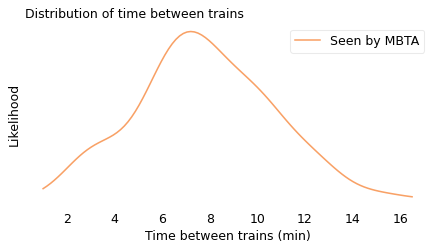

In [21]:
xs = np.linspace(1, 16.5, 101)
kdeplot(unbiased, xs, "Seen by MBTA", color="C1")

decorate(
    xlabel="Time between trains (min)", title="Distribution of time between trains"
)

However, and more to my point, this is not the distribution you would
see as a passenger. Assuming that you arrive at a random time, without
any knowledge about when the next train will arrive, you are more likely
to arrive during a long interval; specifically, if an interval is $x$
minutes long, you will oversample it by a factor of $x$.

As in the previous example with class sizes, I simulated this process,
drawing a random sample from the observed intervals with the probability
of choosing each interval proportional to its duration. In the following figure,
the dashed line shows the result. In this biased distribution, long
intervals are relatively more likely and short intervals are relatively
less likely; the effect is that the biased distribution is shifted to
the right.

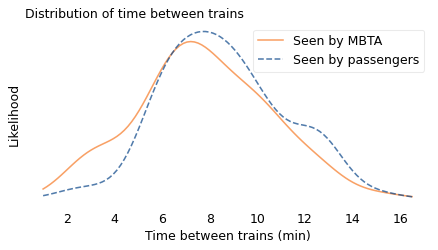

In [22]:
xs = np.linspace(1, 16.5, 101)
kdeplot(unbiased, xs, "Seen by MBTA", color="C1")
kdeplot(biased, xs, "Seen by passengers", ls="--")

decorate(
    xlabel="Time between trains (min)", title="Distribution of time between trains"
)

In [23]:
np.mean(biased), np.mean(unbiased)

(8.570714285714285, 7.7680952380952375)

In [24]:
(np.mean(biased) - np.mean(unbiased)) / np.mean(unbiased) * 100

10.332250352479615

In the actual distribution, the average time between trains is 7.8
minutes; in the biased distribution, as seen by a random passenger, it
is 9.2 minutes, about 20% longer.
In this example, the discrepancy is not very big; if you ride the train
once or twice a day, you might not notice it.

The size of the
discrepancy depends on how much variation there is in the distribution.
If the intervals between trains were all the same size, there would be
no discrepancy at all. But as we'll see in the next example, when the
distribution is highly variable, bias in the sampling process can make a
big difference.

## Are you popular? Hint: no.

In 1991, the sociologist Scott Feld published a seminal paper on the "friendship
paradox", which is the observation that most people have fewer friends
than their friends have. He studied real-life social networks, but the
same effect appears in online networks. For example, if you choose a
random Facebook user and then choose one of their friends at random, the
chance is about 80% that the friend has more friends.

The friendship paradox is a form of the inspection paradox. When you
choose a random user, every user is equally likely. But when you choose
one of their friends, you are more likely to choose someone with a lot
of friends.

To see why, suppose we visit every person in a social network and ask
them to list their friends. If we put all of the lists together, someone
with one friend will appear only once, someone with 10 friends will
appear 10 times, and in general someone with $x$ friends will appear $x$
times.

To demonstrate the effect, I used data from a sample of about 4000
Facebook users. First I computed the number of friends each user has; in
the following figure, the solid line shows this distribution. Most of
the users in this sample have fewer than 50 friends, but a few of them
have more than 200.

In [25]:
# [Stanford Network Analysis Project (SNAP)](http://snap.stanford.edu/).

download("https://snap.stanford.edu/data/facebook_combined.txt.gz")

In [27]:
import networkx as nx


def read_graph(filename, **options):
    """Read a graph from a file.

    filename: string

    return: Graph
    """
    G = nx.Graph()
    array = np.loadtxt(filename, dtype=int, **options)
    G.add_edges_from(array)
    return G

In [28]:
fb = read_graph("facebook_combined.txt.gz")
n = len(fb)
m = len(fb.edges())
n, m

(4039, 88234)

In [29]:
unbiased = [fb.degree(node) for node in fb]
len(unbiased)

4039

In [30]:
np.max(unbiased)

1045

In [31]:
biased = resample_weighted(unbiased, unbiased)

In [32]:
high = 250

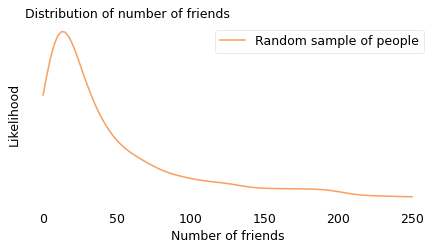

In [33]:
xs = np.linspace(0, high, 101)
kdeplot(unbiased, xs, "Random sample of people", color="C1")

decorate(
    xlabel="Number of friends",
    title="Distribution of number of friends",
)

Then I drew a sample from the list of friends, and counted how many
friends *they* have. In the following figure, the dashed line shows this distribution. Compared
to the unbiased distribution, people with more than 50 friends are
overrepresented; people with fewer friends are underrepresented.

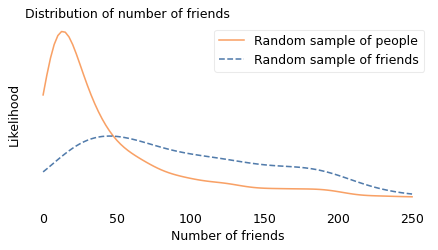

In [34]:
xs = np.linspace(0, high, 101)
kdeplot(unbiased, xs, "Random sample of people", color="C1")
kdeplot(biased, xs, "Random sample of friends", ls="--")

decorate(
    xlabel="Number of friends",
    title="Distribution of number of friends",
)

In [35]:
p = unbiased / np.sum(unbiased)
weighted = np.random.choice(unbiased, 10000, p=p)

In [36]:
edges = np.array(fb.edges)
edges

indices = np.arange(len(edges))
index_sample = np.random.choice(indices, 10000)
edge_sample = edges[index_sample]

index_sample = np.random.choice([0, 1], len(edge_sample))
index_sample

degrees = []
for index, edge in zip(index_sample, edge_sample):
    degree = fb.degree(edge[index])
    degrees.append(degree)

In [37]:
counts = []

people = np.random.choice(fb.nodes, 10000)

for person in people:
    friend = np.random.choice(list(fb.neighbors(person)))
    count = fb.degree(friend)
    counts.append(count)

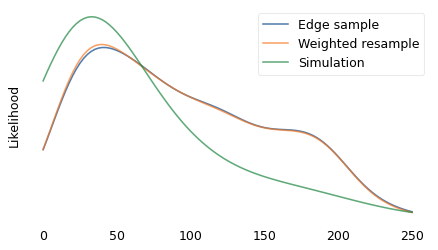

In [38]:
kdeplot(degrees, xs, "Edge sample")
kdeplot(weighted, xs, "Weighted resample")
kdeplot(counts, xs, "Simulation")

The difference between the distributions is substantial: in the unbiased
sample, the average user has 44 friends; in the biased sample, the
average friend has 104, more than twice as many. And if you are a random
person in this sample, the probability that your friend is more popular
than you is about 76%.

But don't feel too bad; even the most charismatic megafauna have the same problem. If you are a bottlenose dolphin in Doubtful Sound, New Zealand, you interact regularly with between 1 and 12 other dolphins, according to the researchers who mapped your social network.
If I choose one of your "friends" at random and compare them to you, the probability is about 65% that your friend has more friends than you.

You might have noticed that the length in "length-biased sampling" is not always an extent in space.
In the class size example, the "length" of a class is the number of students; in the Red Line example, it's the duration of the interval between trains; in the friendship paradox, it's the number of friends.
In the next example, it's the number of people infected by a superspreader.

In [39]:
download("http://nrvis.com/download/data/soc/soc-dolphins.zip")

if not exists('soc-dolphins.mtx'):
    !unzip soc-dolphins.zip

In [40]:
from scipy.io import mmread

array = mmread('soc-dolphins.mtx')
dolphins = nx.from_scipy_sparse_array(array)
n = len(dolphins)
m = len(dolphins.edges())
n, m

(62, 159)

In [41]:
unbiased = [dolphins.degree(node) for node in dolphins]
np.array(unbiased)

array([ 6,  8,  4,  3,  1,  4,  6,  5,  6,  7,  5,  1,  1,  8, 12,  7,  6,
        9,  7,  4,  9,  6,  1,  3,  6,  3,  3,  5,  5,  9,  5,  1,  3, 10,
        5,  1,  7, 11,  8,  2,  8,  5,  6,  7,  4, 11,  2,  6,  1,  2,  7,
       10,  4,  2,  7,  2,  2,  9,  1,  5,  1,  3])

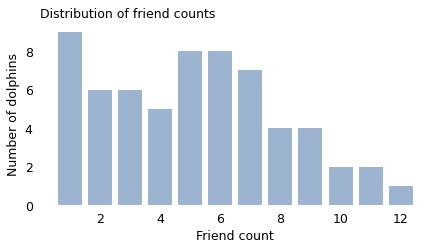

In [42]:
from empiricaldist import Pmf

pmf = Pmf.from_seq(unbiased, normalize=False)
pmf.bar(label="", alpha=0.4)
decorate(
    xlabel="Friend count",
    ylabel="Number of dolphins",
    title="Distribution of friend counts",
)

In [43]:
biased = resample_weighted(unbiased, unbiased)

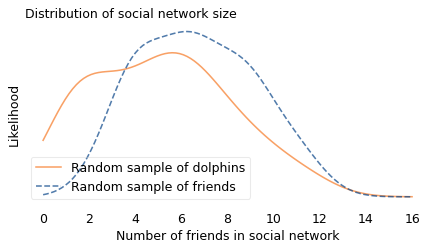

In [44]:
high = 16
xs = np.linspace(0, high, 101)
kdeplot(unbiased, xs, "Random sample of dolphins", color="C1")
kdeplot(biased, xs, "Random sample of friends", ls="--")

decorate(
    xlabel="Number of friends in social network",
    title="Distribution of social network size",
)

In [45]:
np.mean(biased), np.mean(unbiased)

(6.67741935483871, 5.129032258064516)

In [46]:
np.mean(biased > unbiased)

0.6129032258064516

## Finding Superspreaders

Fortunately, the inspection paradox can do more than make us feel bad.
It can help us find people who feel bad; more specifically, it can help
us find people spreading a disease.

During the COVID-19 pandemic, you probably heard about the
effective reproduction number, $R$, which is the average number of
people infected by each infected person. $R$ is important because it
determines the large-scale course of the epidemic. As long as $R$ is
greater than 1, the number of cases grows exponentially; if it drops below 1, the number of cases dwindles toward zero.

However, $R$ is an average, and the average is not the whole story. With
COVID-19, like many other epidemics, there is a lot of variation around
the average.
According to a news feature in *Nature*, "One study in Hong Kong found
that 19% of cases of COVID-19 were responsible for 80% of transmission,
and 69% of cases didn't transmit the virus to anyone." In other words,
most infections are caused by a small number of superspreaders.

This observation suggests a strategy for contact tracing. When an
infected patient is discovered, it is common practice to identify people
they have been in contact with who might also be infected. "Forward
tracing" is intended to find people the patient might have infected;
"backward tracing" is intended to find the person who infected the
patient.

Now suppose you are a public health officer trying to slow or stop the
spread of a communicable disease. Assuming that you have limited
resources to trace contacts and test for the disease -- and that's a
pretty good assumption -- which do you think would be more effective,
forward or backward tracing?

The inspection paradox suggests that backward tracing is more likely to
discover a superspreader and the people they have infected.

According to the Nature article, "Backward tracing is extremely
effective for the coronavirus because of its propensity to be passed on
in superspreading events [...] Any new case is more likely to have
emerged from a cluster of infections than from one individual, so
there's value in going backwards to find out who else was linked to that
cluster."

To quantify this effect, let's suppose that 70% of infected people don't infect anyone else, as in the Hong Kong study, and the other 30% infect between 1 and 15 other people, uniformly distributed. The average of this distribution is 2.4, which is a plausible value of $R$.

Now suppose we discover an infected patient, trace forward, and find
someone the patient infected. On average, we expect this person to
infect 2.4 other people.

But if we trace backward and find the person who infected the patient,
we are more likely to find someone who has infected a lot of people, and
less likely to find someone who has infected only a few. In fact, the
probability that we find any particular spreader is proportional to the
number of people they have infected.

In [47]:
import numpy as np

t1 = np.arange(1, 16)
t2 = [0] * 70
unbiased = np.concatenate([t1, t1, t2])
unbiased

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,  1,  2,
        3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])

In [48]:
np.mean(unbiased)

2.4

Here's the mean of the biased distribution.

In [49]:
biased = resample_weighted(unbiased, unbiased)
np.mean(biased)

10.14

In [50]:
np.mean(biased) / np.mean(unbiased)

4.2250000000000005

By simulating this sampling process, we can compute the distribution we
would see by backward tracing. The average of this biased distribution
is 10.1, more than four times the average of the unbiased distribution.
This result suggests that backward tracing can discover four times more
cases than forward tracing, given the same resources.

This example is not just theoretical; Japan adopted this strategy in
February 2020. As Michael Lewis describes in *The Premonition*:

> "When the Japanese health authorities found a new case, they did not
waste their energy asking the infected person for a list of contacts
over the previous few days, to determine whom the person might have
infected in turn. [...] Instead, they asked for a list of people with
whom the infected person had interacted further back in time. Find
the person who had infected the newly infected person and you might have
found a superspreader. Find a superspreader and you could track down the
next superspreader before [they] really got going."

So the inspection paradox is not always a nuisance; sometimes we can use
it to our advantage.

## Road Rage

Now let's get back to the example at the beginning of the chapter, based
on my experience running a 209-mile relay race. To recap, I noticed
something unusual when I joined the race: when I overtook slower
runners, they were usually much slower; and when faster runners passed
me, they were usually much faster. At first I thought the distribution
of runners had two modes, with many slow runners, many fast runners, and
few runners like me in the middle. Then I realized I was being fooled by
the inspection paradox.

In long relay races, runners at different speeds end up spread out over the course with no relationship between their speed and location.
So if you jump into the middle of the race, the people near you are something like a random sample of the runners in the race.

Considering first the runners behind you, someone running much faster than you is more likely to overtake you during your time on the course than someone just a little bit faster.
And, considering the runners in front of you, someone running much slower than you is more likely to be overtaken than someone just a little bit slower.
Finally, if someone is running at the same speed as you, you might see them if they happen to be nearby when you join the race, but otherwise there is no chance that you will pass them or them you.

So the sample of runners you see depends on your speed. 
Specifically, your chance of seeing another runner is proportional to the difference between your speed and theirs.

We can simulate this effect using data from a conventional road race.
In the following figure, the solid line shows the actual distribution of
speeds from the James Joyce Ramble, a 10K race in Massachusetts.
This is the distribution a spectator would see if they watched all of the runners go by.
The dashed line shows the biased distribution that would be seen by a runner going 11 kilometers per hour (kph).

In [51]:
download("https://web.archive.org/web/20100429073703/http://coolrunning.com/results/10/ma/Apr25_27thAn_set1.shtml")

In [52]:
from bs4 import BeautifulSoup

soup = BeautifulSoup(open("Apr25_27thAn_set1.shtml"), "html.parser")

In [53]:
import pandas as pd

speeds = pd.Series([], dtype=float)

table = soup.find("pre")
for line in table.text.split("\n"):
    t = line.split()
    if len(t) in [13, 14]:
        place, place_in_div, div, gun, net, pace = t[0:6]
        place = int(place)
        m, s = [int(x) for x in pace.split(":")]
        secs = m * 60 + s
        kph = 1.61 / secs * 60 * 60
        speeds[place] = kph

len(speeds)

1591

In [54]:
unbiased = speeds.values

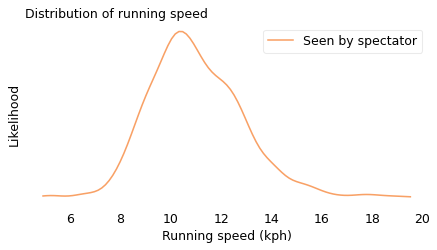

In [55]:
xs = np.linspace(speeds.min(), speeds.max(), 101)
kdeplot(unbiased, xs, "Seen by spectator", color="C1")

decorate(xlabel="Running speed (kph)", title="Distribution of running speed")

And here's the biased view seen by someone running 11 kph.

In [56]:
weights = np.abs(unbiased - 11)
biased = resample_weighted(unbiased, weights)

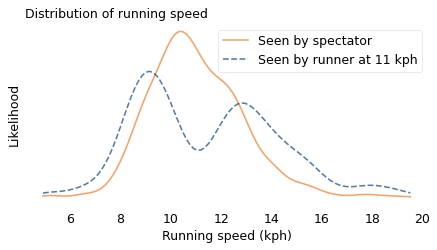

In [57]:
kdeplot(unbiased, xs, "Seen by spectator", color="C1")
kdeplot(biased, xs, "Seen by runner at 11 kph", ls="--")

decorate(xlabel="Running speed (kph)", title="Distribution of running speed")

In the actual distribution, there are a lot of runners near 11 kph, but if you run at that speed, you are unlikely to see them. 
As a result, the biased distribution has few runners near 11 kph and more at the extremes.
And it has two modes, one near 9 kph and one near 13 kph.
So that explains my oxygen-deprived confusion.

If you are not a runner, you might have noticed the same effect on the highway.
You are more likely to see drivers who go too fast or too slow, and less likely to see safe, reasonable drivers like yourself.
George Carlin summed it up:

> Have you ever noticed when you're driving that anyone driving slower than you is an idiot and anyone driving faster than you is a maniac? 
[...] Because there's certainly no one driving at my speed.

## Just Visiting

Another example of the inspection paradox occurred to me when I read
*Orange is the New Black*, a memoir by Piper Kerman, who spent 13 months
in a federal prison. Kerman expresses surprise at the length of the
sentences her fellow prisoners are serving. She is right to be
surprised, but it turns out that she is not just the victim of an
inhumane prison system; she has also been misled by the inspection
paradox.

If you visit a prison at a random time and choose a random prisoner, you
are more likely to find a prisoner with a long sentence.
By now, you probably see the pattern: a prisoner with sentence $x$ is overrepresented by a factor of $x$.

To see what difference it makes, I downloaded data from the U.S. Federal Bureau of Prisons (BOP).
Each month, they report the distribution of sentences for current inmates in federal prisons.
So the result is a biased sample.
However, we can use the reported data to estimate the unbiased distribution, as we did with students and class sizes.

In the following figure, the dashed line shows the distribution of sentences as reported by the BOP.
The solid line shows the unbiased distribution I estimated.


In [58]:
# here's how I read the file, but this doesn't work on windows

#tables = pd.read_html("BOP Statistics_ Sentences Imposed.html")
#df = tables[0]

# so here's the CSV version I saved

download(
    "https://github.com/AllenDowney/ProbablyOverthinkingIt/raw/book/data/BOP_Statistics_Sentences_Imposed.csv"
)

In [60]:
df = pd.read_csv('BOP_Statistics_Sentences_Imposed.csv', index_col=0)
df

,Sentence,# of Inmates,% of Inmates
0,0 to 1 year*,5155,2.3 %
1,> 1 year to < 3 years**,18619,11.3%
2,3 years to < 5 years,17897,10.9%
3,5 years to < 10 years,41887,25.4%
4,10 years to < 15 years,34995,21.3%
5,15 years to < 20 years,18674,11.3%
6,20 years or more but < Life,22738,13.8%
7,Life,4600,2.8%


Here are the low and high sentences for each range.
I assume that the minimum sentence is about a week,
that sentences "less than life" are 40 years,
and that a life sentence is between 40 and 60 years.

In [61]:
sentences = [(0.02, 1), (1, 3), (3, 5), (5, 10), (10, 15), (15, 20), (20, 40), (40, 60)]

In [62]:
counts = df["# of Inmates"]

In [63]:
def sample_from_bins(sizes, counts):
    """Generate a sample from binned data by sampling uniformly within each bin.

    Takes histogram-style binned data (ranges and counts) and generates
    a sample by drawing uniform random values within each bin range.
    This "expands" the binned data back into a continuous sample.

    sizes: sequence of (low, high) pairs representing bin boundaries
    counts: sequence of integers representing counts in each bin

    returns: NumPy array of sampled values
    """
    t = []
    for (low, high), count in zip(sizes, counts):
        sample = np.random.uniform(low, high, count)
        t.extend(sample)
    return np.array(t)

In [64]:
biased = sample_from_bins(sentences, counts)

In [65]:
weights = 1 / (0.85 * np.array(biased))

In [66]:
unbiased = resample_weighted(biased, weights)

In the following figure, the dashed line shows the distribution of sentences as reported by the BOP.
The solid line shows the unbiased distribution I estimated.

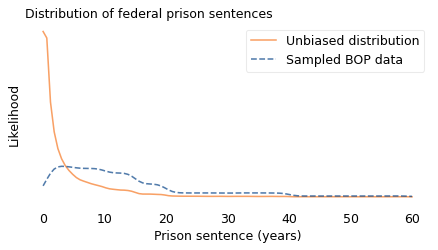

In [67]:
xs = np.linspace(0, 60, 101)
kdeplot(unbiased, xs, "Unbiased distribution", color="C1")
kdeplot(biased, xs, "Sampled BOP data", ls="--")

decorate(
    xlabel="Prison sentence (years)", title="Distribution of federal prison sentences"
)

In the BOP sample, sentences less than three years are underrepresented and longer sentences are overrepresented.

If you work at a prison, and your job is to check in prisoners on their first day, you would see an unbiased sample.
If you visit a prison and choose a prisoner at random, you see a biased sample.
But what happens if you observe a prison over an interval like 13 months?
If the length of your stay is $y$, the chance of overlapping with a prisoner whose sentence is $x$ is proportional to $x + y$.

In the following figure, the dotted line shows what the resulting sample looks like when $y$ is 13 months.

In [68]:
x = 0.85 * unbiased
y = 13 / 12

weights = x + y

In [69]:
kerman = resample_weighted(unbiased, weights)

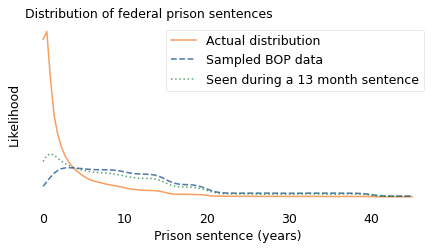

In [70]:
xs = np.linspace(0, 45, 101)
kdeplot(unbiased, xs, 'Actual distribution', color='C1')
kdeplot(biased, xs, 'Sampled BOP data', ls='--')
kdeplot(kerman, xs, 'Seen during a 13 month sentence', color='C2', ls=':')

decorate(xlabel='Prison sentence (years)',
         title='Distribution of federal prison sentences')


Someone like Kerman, who served a relatively short sentence, is more likely to see other short-timers, compared to a one-time visitor, and a little less likely to oversample people with long sentences -- but not by much.
The distribution she observed is substantially different from the actual distribution.
We can summarize the differences like this:

*   The mean of the actual distribution is 3.6 years; the mean of the biased distribution is almost 13 years, more than three times longer! To a 13-month observer, the mean is about 10 years, still much greater than the actual mean.

*   In the actual distribution, about 45% of prisoners have sentences less than a year. If you visit a prison once, fewer than 5% of the prisoners you see are short-timers. If you stay for 13 months, your estimate is better but still not accurate: about 15% of the prisoners you meet are short-timers.

But that's not the only way the inspection paradox distorts our perception of the criminal justice system.

In [71]:
# In the unbiased distribution, almost half of prisoners serve less than one year.

np.mean(unbiased < 1)

0.44923890256129795

In [72]:
np.mean(biased < 1)

0.0313250083553611

In [73]:
np.mean(kerman < 1)

0.1415185489016498

In [74]:
np.mean(unbiased)

3.5733885575130913

In [75]:
np.mean(biased)

12.77324871632595

In [76]:
np.mean(kerman)

10.246041891086158

## Recidivism

A 2016 paper in the journal *Crime & Delinquency* showed how the inspection paradox affects our estimates of recidivism, that is, the number of people released from prison who later return to prison.
By that definition, prior reports estimated that 45% to 50% of people released from state prisons returned to prison within three years.

But those reports use "event-based" samples, that is, prisoners selected based on an event like their release from prison.
That sampling process is biased because someone imprisoned more than once is more likely to appear in the sample.
The alternative is an individual-based sample, where every prisoner is equally likely to appear, regardless of how many sentences they serve.

In an event-based sample, recidivists are oversampled, so the recidivism rate is higher.
Using data from the paper, we can find out how much higher.
Based on data from 17 states, collected between 2000 and 2012, the authors compute the number of admissions to prison in an event-based sample, shown in the following figure.

In [77]:
from empiricaldist import Pmf

ps = [0.51, 0.25, 0.13, 0.07, 0.03, 0.01]
ks = np.arange(1, len(ps) + 1)
pmf = Pmf(ps, ks)
pmf.sum()

1.0

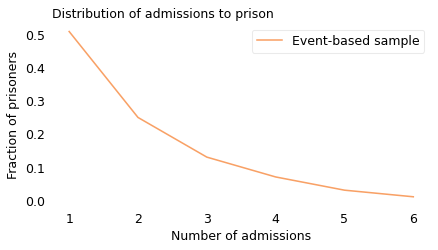

In [78]:
pmf.plot(color="C1", label="Event-based sample")

decorate(
    xlabel="Number of admissions",
    ylabel="Fraction of prisoners",
    title="Distribution of admissions to prison",
)

In [79]:
# fraction of recidivists in the event-based sample

1 - pmf[1]

0.49

In this sample, 51% of the prisoners served only one sentence; the other 49% were recidivists. So that's consistent with results from previous reports.

We can use this data to simulate an individual-based sample.
In the following figure, the dashed line shows the result.

In [80]:
unbiased = pmf / ks
unbiased.normalize()

# fraction of recidivists in biased sample
1 - unbiased[1], unbiased[1]

(0.2750533049040512, 0.7249466950959488)

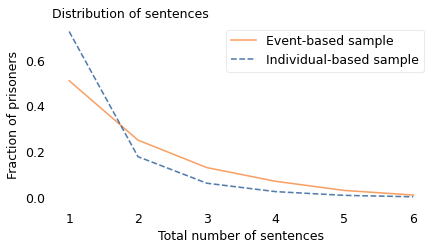

In [81]:
pmf.plot(color="C1", label="Event-based sample")
unbiased.plot(ls="--", label="Individual-based sample")

decorate(
    xlabel="Total number of sentences",
    ylabel="Fraction of prisoners",
    title="Distribution of sentences",
)

In [82]:
pmf.mean(), unbiased.mean()

(1.89, 1.421464108031272)

In the individual-based sample, most prisoners serve one sentence; only 28% are recidivists.
That's substantially lower than the recidivism rate in the event-based sample, which is 49%.
Neither of these statistics is wrong, but they answer different questions.

The individual-based sample tells us what fraction of the people who ever serve time are recidivists.
If we want to know whether prison is effective at deterring crime, or evaluate a new program intended to reduce recidivism, this might be a useful statistic to consider.
By this standard, the outcome is relatively good; as the authors of the paper observe, "most offenders who enter and exit prison do not return."

The event-based sample tells us what fraction of the people released from prison during a short interval are recidivists.
This statistic pertains to the risk of recidivism, but might not be the most useful because it does not distinguish people who have already served multiple sentences from those who will.
And, due to the inspection paradox, the event-based sample "exaggerates the failure rate of offenders", which "may fuel a pessimistic view that nothing works, or at least that nothing works very well."

A related phenomenon might affect the perception of a police officer who arrests the same person more than once.
They might feel like the exercise is futile, but their sample is biased.
On any given day, they are more likely to interact with a career criminal, less likely to
encounter a one-timer, and even less likely to interact with a law-abiding citizen.
If they are not aware of this bias, it might make their perception of criminal justice bleaker than the reality.

## It's Everywhere

Once you become aware of the inspection paradox, you see it everywhere.

When I teach my Data Science class, I ask students how big their families are and compute the average. Every semester, the result is higher than the natural average. Do my students come from unusually big families? No, my sampling process is biased. If a family has many children, it is more likely that one of them will be in my class. In general, families with $x$ children are overrepresented by a factor of $x$.

When you call customer service, why is the call center *always* experiencing "higher than normal call volume"? Because when they are busy, many people hear this message; when they are less busy, there are fewer customers to enjoy it.

Airlines complain that too many flights are nearly empty; at the same time, passengers complain that too many planes are full. Both could be true. When a flight is nearly empty, only a few passengers enjoy the extra space. But when a flight is full, many passengers feel the crunch.

In summary, the inspection paradox appears in many domains, sometimes in subtle ways. If you are not aware of it, it can cause statistical errors and lead to invalid conclusions. But in many cases it can be avoided, or even used deliberately as part of an experimental design.

## Sources and related reading

*   The class size data from Purdue University is no longer on their web page, but it is available from the Internet Archive ([Purdue University, 2016](https://web.archive.org/web/20160415011613/https://www.purdue.edu/datadigest/2013-14/InstrStuLIfe/DistUGClasses.html)).

*   Information about the Red Line data is available from the MBTA ([Massachusetts Bay Transportation Authority, 2021](https://www.mbta.com/developers)).

*   Feld's original paper about the friendship paradox is "Why Your Friends Have More Friends Than You Do" ([Feld, 1991](http://www.jstor.org/stable/2781907)). In 2011, a group of researchers published a study of 721 million Facebook users that quantified the friendship paradox ([Ugander et al., 2011](https://arxiv.org/abs/1111.4503)). I don't have access to their data, so I worked with a much smaller subset from a 2012 paper ([McAuley & Leskovec, 2012](http://papers.nips.cc/paper/4532-learning-to-discover-social-circles-in-ego-networks)), which is available from the Network Data Repository ([Rossi & Ahmed, 2015](http://networkrepository.com)).

*   John Allen Paulos presented the friendship paradox in *Scientific American* ([Paulos, 2011](https://www.scientificamerican.com/article/why-youre-probably-less-popular-than-your-friends/)). Steven Strogatz wrote about it, as well as the class size paradox, in *The New York Times* ([Strogatz, 2012](https://opinionator.blogs.nytimes.com/2012/09/17/friends-you-can-count-on)).

*   The dolphin data is originally from a paper in *Behavioral Ecology and Sociobiology* ([Lusseau et al., 2003](https://link.springer.com/article/10.1007/s00265-003-0651-y)); I downloaded it from the Network Data Repository ([Rossi & Ahmed, 2015](http://networkrepository.com)).

*   Michael Lewis wrote about contact tracing in *The Premonition* (Penguin UK, 2021), based in part on an article in *Nature* ([Lewis, 2020](https://www.nature.com/articles/d41586-020-03518-4)).

*   Zeynep Tufekci wrote about superspreaders in *The Atlantic* ([Tufekci, 2020](https://www.theatlantic.com/health/archive/2020/09/k-overlooked-variable-driving-pandemic/616548/)).

*   The running speed data is originally from Cool Running, now available from the Internet Archive ([Cool Running, 2010](https://web.archive.org/web/20100429073703/http://coolrunning.com/results/10/ma/Apr25_27thAn_set1.shtml)).

*   I got data on the duration of prison sentences from the website of the Federal Bureau of Prisons ([Federal Bureau of Prisons, 2019](https://www.bop.gov/about/statistics/statistics_inmate_sentences.jsp)).

*   The paper on recidivism is Rhodes et al., "Following incarceration, most released offenders never return to prison" ([Rhodes et al., 2016](https://journals.sagepub.com/doi/abs/10.1177/0011128715613404)).